# Exercise 1

Create a model using K-Nearest Neigbors to perform classification using the personality dataset.

0 -'introvert'

1 - 'extrovert'

## A. Import libraries

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

data = {
    "name": [
        "Mich", "Ella", "Kevin", "Recio", "Mark",
        "Loraine", "Carlo", "Chiar", "Lujille", "Kyla",
        "Sean", "Saren", "Liam", "Cas", "Dexter"
    ],
    "followers": [
        250, 50, 120, 30, 500,
        450, 600, 80, 300, 150,
        220, 400, 90, 275, 130
    ],
    "friends": [
        311, 20, 80, 15, 300,
        250, 400, 25, 200, 100,
        180, 350, 60, 240, 110
    ],
    "personality": [
        0, 0, 0, 0, 1,
        1, 1, 0, 1, 0,
        1, 1, 0, 1, 0
    ]
}

df = pd.DataFrame(data)

## B. Load and understand the dataset

Display the first 5 rows of the dataset using `.head()`

In [21]:
df.head()

,name,followers,friends,personality
0,Mich,250,311,0
1,Ella,50,20,0
2,Kevin,120,80,0
3,Recio,30,15,0
4,Mark,500,300,1


Display the summary of all the features of the dataset using `.info()`

In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   name         15 non-null     object
 1   followers    15 non-null     int64 
 2   friends      15 non-null     int64 
 3   personality  15 non-null     int64 
dtypes: int64(3), object(1)
memory usage: 612.0+ bytes


Display the total number of samples from each label using `.value_counts()`

In [23]:
df["personality"].value_counts()

,count
personality,
0,8
1,7


Use a histogram to display the number of followers for each samples
 - The x axis should be the number of followers/friends
 - The y axis should be the number of samples in the dataset

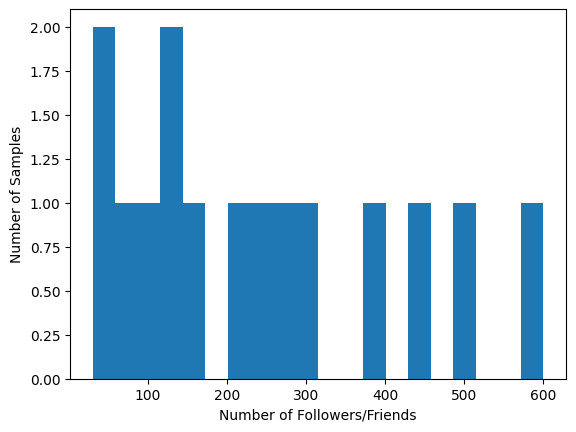

In [24]:
import matplotlib.pyplot as plt

plt.hist(df["followers"], bins=20)
plt.xlabel("Number of Followers/Friends")
plt.ylabel("Number of Samples")
plt.show()

Remove the name column using `drop()` method

In [25]:
df = df.drop("name", axis=1)

## C. Split the dataset into training and test set

Convert the features into an numpy array using `.values()` and store it in a variable "X"

In [26]:
X = df.drop("personality", axis=1).values

Convert the labels into an numpy array using `.values()` and store it in a variable "y"

In [27]:
y = df["personality"].values

Use `train_test_split()` to split the data.

- Declare a variable `X_train` that will hold the training data
- Declare a variable `X_test` that will hold the test data
- Declare a variable `y_train` that will hold the label of the training data
- Declare a variable `y_test` that will hold the label of the test data


In [28]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

Display the dimensions of each variables using `.shape()`

In [29]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(12, 2)
(3, 2)
(12,)
(3,)


## D. Create the model

Use KNN as a classifier by using `KNeighborsClassifier()`

In [30]:
model = KNeighborsClassifier()

Train the model using the `.fit()`

In [31]:
model.fit(X_train, y_train)

KNeighborsClassifier()

Test the model using the `.predict()`

In [32]:
y_pred = model.predict(X_test)

## E. Evaluate the model

Create a confusion matrix

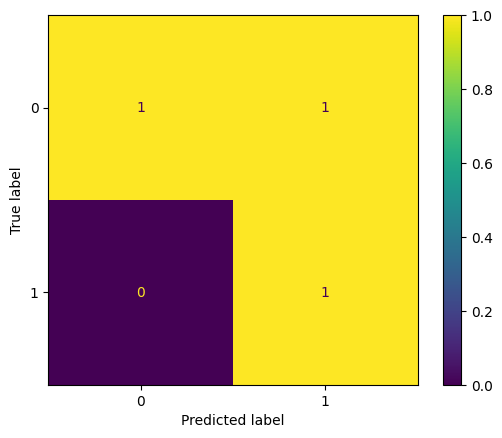

In [33]:
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(confusion_matrix=cm).plot()

Display the accuracy

In [34]:
print(accuracy_score(y_test, y_pred))

0.6666666666666666


Display the precision

In [35]:
print(precision_score(y_test, y_pred))

0.5


Display the recall

In [36]:
print(recall_score(y_test, y_pred))

1.0


Display the f1-score

In [37]:
print(f1_score(y_test, y_pred))

0.6666666666666666


## F. Predict your own personality

Enter your own features and use the model to generate a prediction using `.predict()`

In [38]:
my_features = [[15, 31]]
prediction = model.predict(my_features)

print(prediction)

if prediction[0] == 0:
    print("Introvert")
else:
    print("Extrovert")

[0]
Introvert
